# **Setup**

In [1]:
!pip install torch torchvision opencv-python matplotlib tqdm
!git clone https://github.com/facebookresearch/segment-anything.git
%cd segment-anything
!pip install -e .

Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 18.31 MiB | 18.10 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/segment-anything
Obtaining file:///content/segment-anything
  Preparing metadata (setup.py) ... done
  Running setup.py develop for segment_anything


# **Import**

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

# **Load SAM**

In [6]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-05-04 18:21:55--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.52, 65.9.168.62, 65.9.168.4, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  35.6MB/s    in 5.9s    

2026-05-04 18:22:01 (60.7 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [7]:
from segment_anything import sam_model_registry

device = "cuda"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

for p in sam.parameters():
    p.requires_grad = False

# **LoRA**

Attention QKV

In [69]:
class LoRA_QKV(nn.Module):
    def __init__(self, orig, rank=4):
        super().__init__()
        self.orig = orig
        in_dim = orig.in_features
        out_dim = orig.out_features

        self.A = nn.Linear(in_dim, rank, bias=False)
        self.B = nn.Linear(rank, out_dim, bias=False)

    def forward(self, x):
        return self.orig(x) + self.B(self.A(x))


def inject_lora(model):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and module.out_features == module.in_features * 3:
            parent = model
            *path, last = name.split('.')
            for p in path:
                parent = getattr(parent, p)
            setattr(parent, last, LoRA_QKV(module))
    return model

sam.image_encoder = inject_lora(sam.image_encoder)

# **COBOT**

In [70]:
class COBOT(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim, 1)

    def forward(self, feats):
        # feats = list, but we only use last feature
        x = feats[-1]
        return self.proj(x)

# **Encoder Hook**

In [71]:
def forward_encoder(model, x):
    # SAM handles everything internally
    x = model.patch_embed(x)

    feats = []

    for blk in model.blocks:
        x = blk(x)
        feats.append(x)

    return feats, x

# **Model**

In [72]:
class SAM_COBOT(nn.Module):
    def __init__(self, sam):
        super().__init__()
        self.image_encoder = sam.image_encoder
        self.prompt_encoder = sam.prompt_encoder
        self.mask_decoder = sam.mask_decoder

        self.cobot = COBOT()

    def forward(self, image, boxes):
        with torch.no_grad():
            image_embedding = self.image_encoder(image)  # [B,256,64,64]

        # COBOT (optional refinement)
        image_embedding = self.cobot([image_embedding])

        sparse, dense = self.prompt_encoder(
            points=None,
            boxes=boxes,
            masks=None,
        )

        masks, _ = self.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse,
            dense_prompt_embeddings=dense,
            multimask_output=False,
        )

        return masks

# **Synthetic Dataset**

In [73]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import random

class SyntheticRemoteDataset(Dataset):
    def __init__(self, num_samples=300, size=1024):
        self.num_samples = num_samples
        self.size = size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Create blank image
        img = np.zeros((self.size, self.size, 3), dtype=np.uint8)

        # Random bounding box
        x1 = random.randint(50, 300)
        y1 = random.randint(50, 300)
        w = random.randint(50, 150)
        h = random.randint(50, 150)

        x2 = min(x1 + w, self.size - 1)
        y2 = min(y1 + h, self.size - 1)

        # Draw object
        img[y1:y2, x1:x2] = np.random.randint(100, 255, 3)

        # ✅ FIXED noise addition (no dtype error)
        img = img.astype(np.int32)
        noise = np.random.randint(0, 50, (self.size, self.size, 3)).astype(np.int32)
        img = img + noise
        img = np.clip(img, 0, 255).astype(np.uint8)

        # Mask
        mask = np.zeros((self.size, self.size), dtype=np.float32)
        mask[y1:y2, x1:x2] = 1.0

        # Convert to tensors
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        mask = torch.tensor(mask).unsqueeze(0)
        box = torch.tensor([[x1, y1, x2, y2]]).float()

        return img, box, mask



# **DataLoader**

In [74]:
dataset = SyntheticRemoteDataset(num_samples=100, size=1024)

dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True
)

# **Loss + IoU**

In [75]:
def dice_loss(pred, target):
    pred = pred.sigmoid()
    inter = (pred * target).sum()
    return 1 - (2*inter+1)/(pred.sum()+target.sum()+1)

def loss_fn(pred, target):
    return F.binary_cross_entropy_with_logits(pred,target) + dice_loss(pred,target)

def compute_iou(pred, target):
    pred = (pred>0.5).float()
    inter = (pred*target).sum()
    union = pred.sum()+target.sum()-inter
    return (inter/(union+1e-6)).item()

In [80]:
import torch

def compute_iou(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    return (intersection / (union + 1e-6)).mean().item()


def compute_dice(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    return ((2 * intersection) / (pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + 1e-6)).mean().item()

# **Training**

In [81]:
model = SAM_COBOT(sam).to(device)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

losses, ious, dices = [], [], []

for epoch in range(8):
    model.train()
    total_loss, total_iou, total_dice = 0, 0, 0

    for img, box, mask in dataloader:
        img, box, mask = img.to(device), box.to(device), mask.to(device)

        pred = model(img, box)

        pred = torch.nn.functional.interpolate(
            pred,
            size=mask.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_iou += compute_iou(pred.sigmoid(), mask)
        total_dice += compute_dice(pred.sigmoid(), mask)

    losses.append(total_loss / len(dataloader))
    ious.append(total_iou / len(dataloader))
    dices.append(total_dice / len(dataloader))

    print(f"Epoch {epoch}: Loss={losses[-1]:.4f}, IoU={ious[-1]:.4f}, Dice={dices[-1]:.4f}")

Epoch 0: Loss=0.1336, IoU=0.8093, Dice=0.8823
Epoch 1: Loss=0.0489, IoU=0.9177, Dice=0.9570
Epoch 2: Loss=0.0381, IoU=0.9347, Dice=0.9661
Epoch 3: Loss=0.0300, IoU=0.9478, Dice=0.9731
Epoch 4: Loss=0.0259, IoU=0.9549, Dice=0.9769
Epoch 5: Loss=0.0209, IoU=0.9636, Dice=0.9815
Epoch 6: Loss=0.0180, IoU=0.9686, Dice=0.9840
Epoch 7: Loss=0.0162, IoU=0.9717, Dice=0.9856


# **Plot**

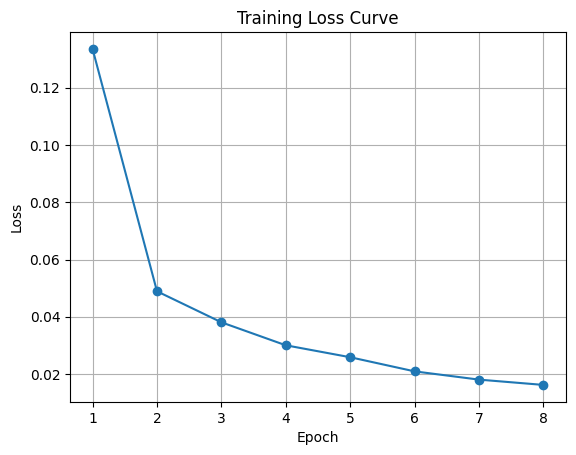

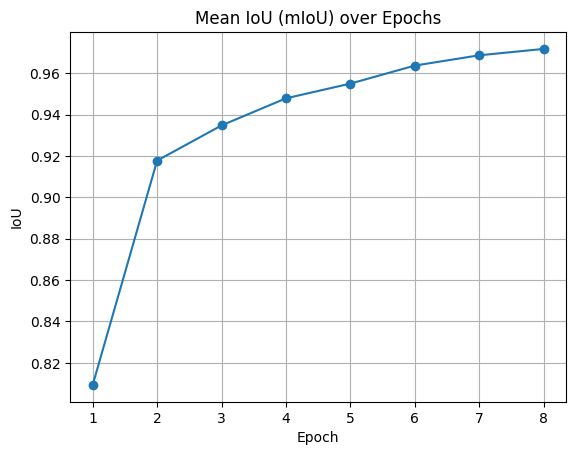

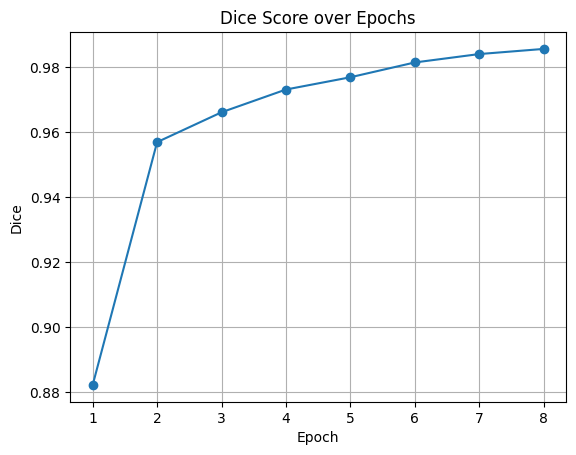

In [82]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(losses)+1))

# --- Loss Curve ---
plt.figure()
plt.plot(epochs, losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# --- IoU Curve ---
plt.figure()
plt.plot(epochs, ious, marker='o')
plt.title("Mean IoU (mIoU) over Epochs")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(True)
plt.show()

# --- Dice Curve ---
plt.figure()
plt.plot(epochs, dices, marker='o')
plt.title("Dice Score over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid(True)
plt.show()

# **Final Results**

In [83]:
print("Final Results:")
print(f"mIoU:  {ious[-1]:.4f}")
print(f"Dice:  {dices[-1]:.4f}")
print(f"Loss:  {losses[-1]:.4f}")

Final Results:
mIoU:  0.9717
Dice:  0.9856
Loss:  0.0162
